In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [11]:
np.random.seed(42)


cluster1 = np.random.multivariate_normal(
    mean=[2, 2],
    cov=[[1, 0.5],
         [0.5, 1]],
    size=250
)


cluster2 = np.random.multivariate_normal(
    mean=[7, 6],
    cov=[[1, -0.3],
         [-0.3, 1]],
    size=250
)


X_normal = np.vstack([cluster1, cluster2])

In [12]:
anomalies = np.array([
    [-2, 7],
    [1, 8],
    [10, 2],
    [11, 8],
    [5, 10],
    [9, 10],
    [-1, 4],
    [12, 5]
])


X = np.vstack([X_normal, anomalies])

In [13]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_normal)

GaussianMixture(n_components=2, random_state=42)

In [14]:
scores = gmm.score_samples(X)

In [15]:
threshold = np.percentile(scores, 2)

print("Anomaly threshold:", threshold)

Anomaly threshold: -6.971986062836184


In [16]:
predicted_anomalies = scores < threshold

print("Number of detected anomalies:",
      predicted_anomalies.sum())

Number of detected anomalies: 11


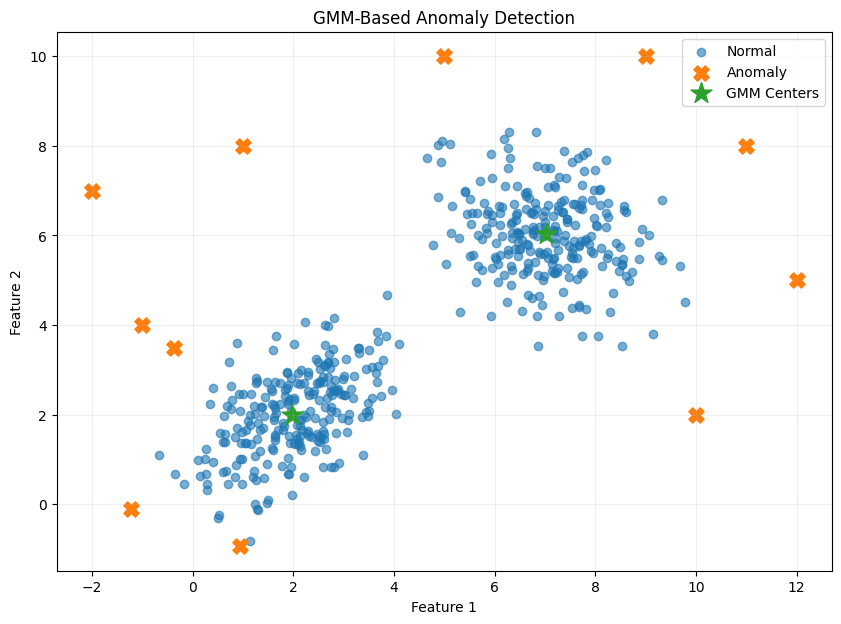

In [17]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X[~predicted_anomalies, 0],
    X[~predicted_anomalies, 1],
    label="Normal",
    alpha=0.6
)


plt.scatter(
    X[predicted_anomalies, 0],
    X[predicted_anomalies, 1],
    marker="X",
    s=120,
    label="Anomaly"
)


plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker="*",
    s=250,
    label="GMM Centers"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM-Based Anomaly Detection")
plt.legend()
plt.grid(alpha=0.2)

plt.show()